## Song Embeddings - Skipgram Recommender

In this notebook, we'll use human-made music playlists to learn song embeddings. We'll treat a playlist as if it's a sentence and the songs it contains as words. We feed that to the word2vec algorithm which then learns embeddings for every song we have. These embeddings can then be used to recommend similar songs. This technique is used by Spotify, AirBnB, Alibaba, and others. It accounts for a vast portion of their user activity, user media consumption, and/or sales (in the case of Alibaba).

The [dataset we'll use](https://www.cs.cornell.edu/~shuochen/lme/data_page.html) was collected by Shuo Chen from Cornell University. The dataset contains playlists from hundreds of radio stations from around the US.

## Importing packages and dataset

In [1]:
import numpy as np
import pandas as pd
import gensim
from gensim.models import Word2Vec
from urllib import request
import warnings
warnings.filterwarnings('ignore')

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


The playlist dataset is a text file where every line represents a playlist. That playlist is basically a series of song IDs.

In [2]:
# Get the playlist dataset file
data = request.urlopen('https://storage.googleapis.com/maps-premium/dataset/yes_complete/train.txt')

# Parse the playlist dataset file. Skip the first two lines as
# they only contain metadata
lines = data.read().decode("utf-8").split('\n')[2:]

# Remove playlists with only one song
playlists = [s.rstrip().split() for s in lines if len(s.split()) > 1]


The `playlists` variable now contains a python list. Each item in this list is a playlist containing song ids. We can look at the first two playlists here:

In [3]:
print( 'Playlist #1:\n ', playlists[0], '\n')
print( 'Playlist #2:\n ', playlists[1])

Playlist #1:
  ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '2', '42', '43', '44', '45', '46', '47', '48', '20', '49', '8', '50', '51', '52', '53', '54', '55', '56', '57', '25', '58', '59', '60', '61', '62', '3', '63', '64', '65', '66', '46', '47', '67', '2', '48', '68', '69', '70', '57', '50', '71', '72', '53', '73', '25', '74', '59', '20', '46', '75', '76', '77', '59', '20', '43'] 

Playlist #2:
  ['78', '79', '80', '3', '62', '81', '14', '82', '48', '83', '84', '17', '85', '86', '87', '88', '74', '89', '90', '91', '4', '73', '62', '92', '17', '53', '59', '93', '94', '51', '50', '27', '95', '48', '96', '97', '98', '99', '100', '57', '101', '102', '25', '103', '3', '104', '105', '106', '107', '47', '108', '109', '110', '111', '112', '113', '25', '63', '62', '114', '115', '84', '116', '117',

## Training the Word2Vec Model
Our dataset is now in the shape the the Word2Vec model expects as input. We pass the dataset to the model.

In [4]:
model = Word2Vec(playlists, vector_size=32, window=20, negative=50, min_count=1, workers=4)

The model is now trained. Every song has an embedding. We only have song IDs, though, no titles or other info. Let's grab the song information file.

## Song Title and Artist File
Let's load and parse the file containing song titles and artists

In [5]:
songs_file = request.urlopen('https://storage.googleapis.com/maps-premium/dataset/yes_complete/song_hash.txt')
songs_file = songs_file.read().decode("utf-8").split('\n')
songs = [s.rstrip().split('\t') for s in songs_file]

In [6]:
songs_df = pd.DataFrame(data=songs, columns = ['id', 'title', 'artist'])
songs_df = songs_df.set_index('id')

In [7]:
songs_df.head()

,title,artist
id,,
0,Gucci Time (w\/ Swizz Beatz),Gucci Mane
1,Aston Martin Music (w\/ Drake & Chrisette Mich...,Rick Ross
2,Get Back Up (w\/ Chris Brown),T.I.
3,Hot Toddy (w\/ Jay-Z & Ester Dean),Usher
4,Whip My Hair,Willow


In [8]:
songs_df.to_csv('songs.csv', index=False)

# Exercise:

Build visualization for the embeddings of the song recommender.

In [9]:
song_ids = list(model.wv.index_to_key)
embeddings = [model.wv[song] for song in song_ids]

In [10]:
song_ids

['20065',
 '5',
 '46',
 '7233',
 '20627',
 '19477',
 '20068',
 '60',
 '82',
 '9659',
 '292',
 '6',
 '20055',
 '344',
 '1',
 '14',
 '475',
 '27076',
 '90',
 '1813',
 '20064',
 '6471',
 '13',
 '7261',
 '19781',
 '2378',
 '50',
 '2373',
 '7303',
 '20054',
 '2198',
 '6488',
 '77',
 '70',
 '1795',
 '2375',
 '19783',
 '9752',
 '288',
 '19782',
 '7255',
 '2251',
 '20047',
 '25',
 '18440',
 '2185',
 '19778',
 '242',
 '2218',
 '85',
 '1832',
 '19786',
 '6602',
 '1792',
 '9342',
 '20668',
 '27074',
 '20634',
 '19767',
 '8721',
 '2244',
 '20052',
 '27051',
 '2212',
 '5437',
 '6790',
 '10157',
 '2189',
 '7244',
 '14144',
 '19789',
 '27560',
 '2280',
 '5505',
 '1406',
 '20048',
 '27550',
 '2231',
 '20020',
 '22259',
 '20005',
 '6470',
 '1803',
 '5889',
 '26398',
 '20242',
 '2192',
 '2246',
 '13873',
 '19574',
 '20059',
 '1885',
 '27080',
 '10149',
 '20150',
 '7248',
 '2224',
 '9678',
 '26394',
 '20618',
 '6775',
 '1155',
 '2191',
 '2423',
 '13877',
 '2183',
 '1421',
 '8382',
 '2204',
 '2384',
 '263

In [11]:
embeddings

[array([-5.6888056 , -0.7678204 ,  1.5364405 ,  1.9808369 , -0.31629398,
        -5.3276176 , -1.9405655 , -2.719927  , -5.5471992 ,  0.46163166,
        -1.0223002 , -0.903244  ,  4.747594  , -0.3590343 ,  3.4588032 ,
         1.5825623 ,  1.2955545 ,  0.16176227,  0.09856772, -0.50889283,
         1.886183  ,  0.35366356, -1.6521403 ,  3.692405  , -0.01970676,
         2.7763124 ,  5.7433724 ,  1.8510904 ,  2.9652998 ,  3.35747   ,
         3.5524654 ,  0.4594037 ], dtype=float32),
 array([-4.1001706 , -0.56172776,  1.7492168 ,  1.8874066 ,  0.098671  ,
        -4.0193877 , -1.4846717 , -2.301916  , -4.744322  ,  0.8066912 ,
        -0.5659132 , -0.39959568,  4.118799  , -0.58518916,  2.9358106 ,
         1.4072351 ,  0.90551275,  0.2724242 ,  0.09641156,  0.18579462,
         1.42164   ,  0.2939741 , -1.3043972 ,  2.702535  , -0.43832684,
         2.0011785 ,  4.9371667 ,  1.5242754 ,  2.5984108 ,  2.899866  ,
         3.258852  ,  0.15226181], dtype=float32),
 array([-4.9436345 , -

In [12]:
embeddings = np.array(embeddings)

tsne = TSNE(n_components=2, random_state=42, perplexity=50)
embeddings_2d = tsne.fit_transform(embeddings)

  File "c:\Users\USUARIO\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\USUARIO\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\USUARIO\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\USUARIO\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


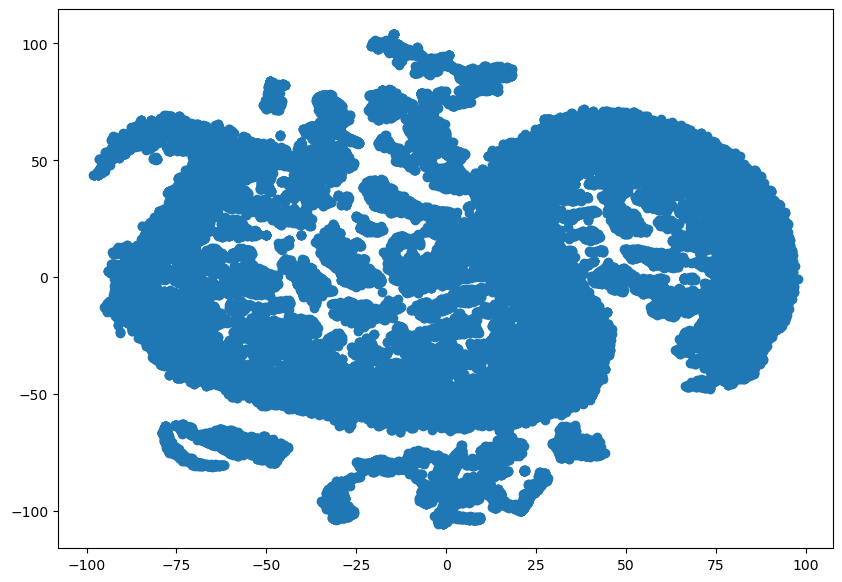

In [13]:
plt.figure(figsize=(10, 7))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])

Este bloque de código tiene como objetivo visualizar de manera bidimensional las representaciones vectoriales (embeddings) generadas por un modelo de tipo Word2Vec para una colección de canciones. Inicialmente, se extraen los identificadores de las canciones (song_ids) desde el vocabulario del modelo, y luego se construye una lista de vectores (embeddings) que representan semánticamente cada canción. Estos vectores son convertidos a un arreglo de NumPy para facilitar su procesamiento. A continuación, se aplica la técnica de reducción de dimensionalidad t-SNE (TSNE) con dos componentes principales (n_components=2) y una perplexity de 50, lo cual permite proyectar los vectores originales de alta dimensión a un espacio bidimensional, conservando al máximo la estructura local de los datos. Finalmente, se utiliza matplotlib para generar una visualización de dispersión (scatter plot), donde cada punto representa una canción en el nuevo espacio reducido, permitiendo observar agrupamientos o patrones semánticos entre las canciones en función de su similitud en el espacio vectorial.

In [14]:
print("Song IDs from Word2Vec:", song_ids)
print("Song IDs from songs_df:", songs_df.index.tolist())

Song IDs from Word2Vec: ['20065', '5', '46', '7233', '20627', '19477', '20068', '60', '82', '9659', '292', '6', '20055', '344', '1', '14', '475', '27076', '90', '1813', '20064', '6471', '13', '7261', '19781', '2378', '50', '2373', '7303', '20054', '2198', '6488', '77', '70', '1795', '2375', '19783', '9752', '288', '19782', '7255', '2251', '20047', '25', '18440', '2185', '19778', '242', '2218', '85', '1832', '19786', '6602', '1792', '9342', '20668', '27074', '20634', '19767', '8721', '2244', '20052', '27051', '2212', '5437', '6790', '10157', '2189', '7244', '14144', '19789', '27560', '2280', '5505', '1406', '20048', '27550', '2231', '20020', '22259', '20005', '6470', '1803', '5889', '26398', '20242', '2192', '2246', '13873', '19574', '20059', '1885', '27080', '10149', '20150', '7248', '2224', '9678', '26394', '20618', '6775', '1155', '2191', '2423', '13877', '2183', '1421', '8382', '2204', '2384', '26350', '20646', '19779', '20046', '3178', '7339', '8404', '5432', '27082', '21949', '597

In [15]:
songs_df.index = songs_df.index.astype(str)

In [16]:
for i, song_id in enumerate(song_ids):
    if song_id in songs_df.index:
        title = songs_df.loc[song_id]['title']
        plt.annotate(title, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=9)

In [17]:
if song_id in songs_df.index.astype(str):
    title = songs_df.loc[str(song_id)]['title']

In [18]:
print("Embedding Shape:", embeddings.shape)
print("Embedding Sample:", embeddings[:5])


Embedding Shape: (75261, 32)
Embedding Sample: [[-5.6888056  -0.7678204   1.5364405   1.9808369  -0.31629398 -5.3276176
  -1.9405655  -2.719927   -5.5471992   0.46163166 -1.0223002  -0.903244
   4.747594   -0.3590343   3.4588032   1.5825623   1.2955545   0.16176227
   0.09856772 -0.50889283  1.886183    0.35366356 -1.6521403   3.692405
  -0.01970676  2.7763124   5.7433724   1.8510904   2.9652998   3.35747
   3.5524654   0.4594037 ]
 [-4.1001706  -0.56172776  1.7492168   1.8874066   0.098671   -4.0193877
  -1.4846717  -2.301916   -4.744322    0.8066912  -0.5659132  -0.39959568
   4.118799   -0.58518916  2.9358106   1.4072351   0.90551275  0.2724242
   0.09641156  0.18579462  1.42164     0.2939741  -1.3043972   2.702535
  -0.43832684  2.0011785   4.9371667   1.5242754   2.5984108   2.899866
   3.258852    0.15226181]
 [-4.9436345  -0.7902067   1.2405101   0.82295114 -1.2791313  -5.888634
  -0.14816824 -1.5633453  -5.346492    0.10638967 -0.8007371  -1.5274668
   3.7351177   0.39828807  2

In [19]:
print("Embedding Shape:", embeddings.shape)

Embedding Shape: (75261, 32)


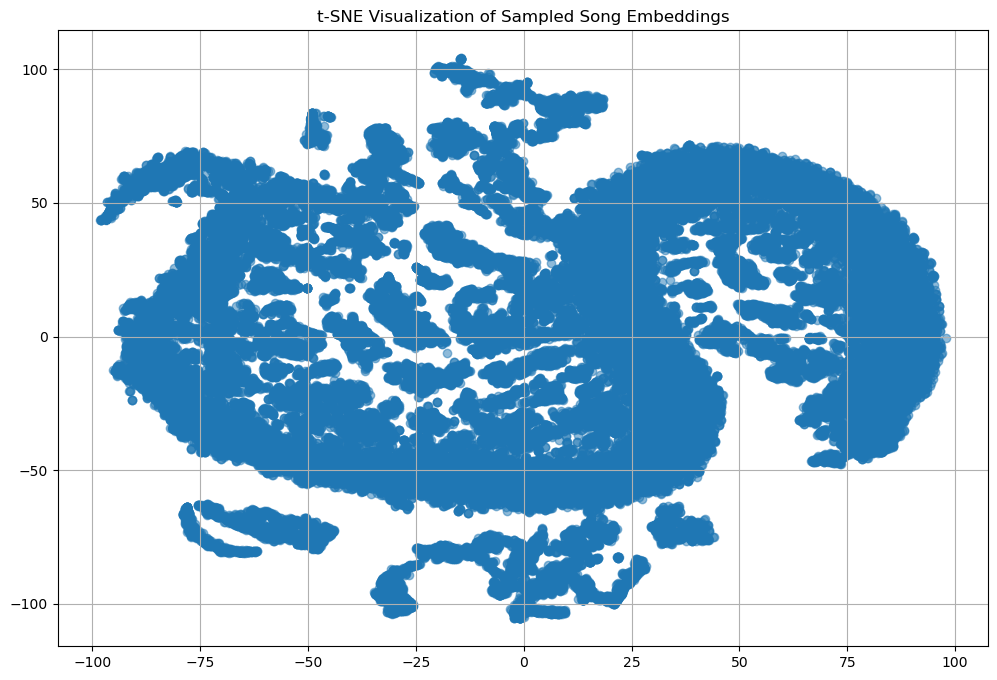

In [20]:
# Visualization
plt.figure(figsize=(12, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5)

# Optional: annotate few points
for i, song_id in enumerate(song_ids):  # only annotate 100 to avoid clutter
    if song_id in songs_df.index:
        title = songs_df.loc[song_id]['title']
        plt.annotate(title, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=6)

plt.title("t-SNE Visualization of Sampled Song Embeddings")
plt.grid(True)
plt.show()

In [22]:
songs_df.head()

,title,artist
id,,
0,Gucci Time (w\/ Swizz Beatz),Gucci Mane
1,Aston Martin Music (w\/ Drake & Chrisette Mich...,Rick Ross
2,Get Back Up (w\/ Chris Brown),T.I.
3,Hot Toddy (w\/ Jay-Z & Ester Dean),Usher
4,Whip My Hair,Willow


Este bloque de código amplía la visualización anterior al añadir anotaciones con los títulos de las canciones sobre el gráfico t-SNE de embeddings. Primero, se imprime por consola la lista de identificadores de canciones (song_ids) obtenida del modelo Word2Vec, así como los índices del DataFrame songs_df, el cual contiene información adicional de las canciones como el título. Para evitar errores en las búsquedas, se convierte el índice de songs_df a tipo str. Luego, se recorre cada song_id del modelo y, si este se encuentra en el DataFrame, se extrae su título y se anota directamente sobre la coordenada correspondiente del gráfico t-SNE. Este proceso se hace dos veces: primero de forma individual para verificar el correcto cruce entre IDs y títulos, y luego durante la generación final del gráfico. En esta visualización final se configura un scatter plot de tamaño más amplio (12x8), con puntos semitransparentes (alpha=0.5) para facilitar la lectura. A modo de optimización visual, sólo se anotan algunos puntos (por ejemplo, 100 o menos) para evitar saturar el gráfico. Finalmente, se incluye un título y una cuadrícula para mejorar la legibilidad del resultado final.


In [26]:
song_ids

['20065',
 '5',
 '46',
 '7233',
 '20627',
 '19477',
 '20068',
 '60',
 '82',
 '9659',
 '292',
 '6',
 '20055',
 '344',
 '1',
 '14',
 '475',
 '27076',
 '90',
 '1813',
 '20064',
 '6471',
 '13',
 '7261',
 '19781',
 '2378',
 '50',
 '2373',
 '7303',
 '20054',
 '2198',
 '6488',
 '77',
 '70',
 '1795',
 '2375',
 '19783',
 '9752',
 '288',
 '19782',
 '7255',
 '2251',
 '20047',
 '25',
 '18440',
 '2185',
 '19778',
 '242',
 '2218',
 '85',
 '1832',
 '19786',
 '6602',
 '1792',
 '9342',
 '20668',
 '27074',
 '20634',
 '19767',
 '8721',
 '2244',
 '20052',
 '27051',
 '2212',
 '5437',
 '6790',
 '10157',
 '2189',
 '7244',
 '14144',
 '19789',
 '27560',
 '2280',
 '5505',
 '1406',
 '20048',
 '27550',
 '2231',
 '20020',
 '22259',
 '20005',
 '6470',
 '1803',
 '5889',
 '26398',
 '20242',
 '2192',
 '2246',
 '13873',
 '19574',
 '20059',
 '1885',
 '27080',
 '10149',
 '20150',
 '7248',
 '2224',
 '9678',
 '26394',
 '20618',
 '6775',
 '1155',
 '2191',
 '2423',
 '13877',
 '2183',
 '1421',
 '8382',
 '2204',
 '2384',
 '263

In [28]:
print(model.wv.key_to_index.keys())

dict_keys(['20065', '5', '46', '7233', '20627', '19477', '20068', '60', '82', '9659', '292', '6', '20055', '344', '1', '14', '475', '27076', '90', '1813', '20064', '6471', '13', '7261', '19781', '2378', '50', '2373', '7303', '20054', '2198', '6488', '77', '70', '1795', '2375', '19783', '9752', '288', '19782', '7255', '2251', '20047', '25', '18440', '2185', '19778', '242', '2218', '85', '1832', '19786', '6602', '1792', '9342', '20668', '27074', '20634', '19767', '8721', '2244', '20052', '27051', '2212', '5437', '6790', '10157', '2189', '7244', '14144', '19789', '27560', '2280', '5505', '1406', '20048', '27550', '2231', '20020', '22259', '20005', '6470', '1803', '5889', '26398', '20242', '2192', '2246', '13873', '19574', '20059', '1885', '27080', '10149', '20150', '7248', '2224', '9678', '26394', '20618', '6775', '1155', '2191', '2423', '13877', '2183', '1421', '8382', '2204', '2384', '26350', '20646', '19779', '20046', '3178', '7339', '8404', '5432', '27082', '21949', '5972', '5969', '2

In [ ]:
print('1234' in model.wv)

True


In [ ]:
print(songs_df.index.dtype) 

object


In [ ]:
songs_df.index = songs_df.index.astype(str)
print(songs_df.index.dtype)  

object


In [33]:
print(model.wv.most_similar('1234', topn=5))

[('4797', 0.999300479888916), ('5069', 0.9960933923721313), ('5165', 0.9953168630599976), ('16555', 0.9945492148399353), ('5145', 0.9944387078285217)]


In [35]:
for sid in ['4797', '5069', '5165', '16555', '5145']:
    print(sid, sid in songs_df.index)

4797 False
5069 False
5165 False
16555 False
5145 False


In [40]:
print("Ejemplo de IDs en Word2Vec:")
print(list(model.wv.index_to_key)[:10])

print("\nEjemplo de IDs en songs_df:")
print(songs_df.index.tolist()[:10])


Ejemplo de IDs en Word2Vec:
['20065', '5', '46', '7233', '20627', '19477', '20068', '60', '82', '9659']

Ejemplo de IDs en songs_df:
['0 ', '1 ', '2 ', '3 ', '4 ', '5 ', '6 ', '7 ', '8 ', '9 ']


In [42]:
songs_df.index = songs_df.index.str.strip()
valid_ids = [sid for sid in model.wv.index_to_key if sid in songs_df.index]
print(f"Total valid songs for recommendation: {len(valid_ids)}")


Total valid songs for recommendation: 75261


In [ ]:

songs_df.index = songs_df.index.astype(str)
songs_df.index = songs_df.index.str.strip()  # <- clave

# --- Función recomendadora ---
def recommend_similar(song_id, top_n=5):
    song_id = str(song_id).strip()
    
    if song_id not in model.wv:
        print(f"Song ID '{song_id}' not in vocabulary.")
        return
    
    similar_songs = model.wv.most_similar(song_id, topn=top_n)
    
    print(f"\nTop {top_n} recommended songs for:", songs_df.loc[song_id]['title'])
    print("="*50)
    
    for sim_song_id, score in similar_songs:
        if sim_song_id in songs_df.index:
            title = songs_df.loc[sim_song_id]['title']
            artist = songs_df.loc[sim_song_id]['artist']
            print(f"{title} by {artist} | similarity: {score:.3f}")
        else:
            print(f"Song {sim_song_id} not found in songs_df | similarity: {score:.3f}")

recommend_similar('5', top_n=5)



Top 5 recommended songs for: Down On Me (w\/ 50 Cent)
All Of The Lights by Kanye West | similarity: 0.996
Moment 4 Life (w\/ Drake) by Nicki Minaj | similarity: 0.992
6 Foot 7 Foot (w\/ Cory Gunz) by Lil Wayne | similarity: 0.988
Look At Me Now (w\/ Lil Wayne & Busta Rhymes) by Chris Brown | similarity: 0.986
No Hands (w\/ Roscoe Dash & Wale) by Waka Flocka Flame | similarity: 0.986


Este segmento de código tiene como propósito implementar y demostrar un sistema de recomendación de canciones utilizando un modelo Word2Vec previamente entrenado. En primer lugar, se inspeccionan ejemplos de identificadores presentes en el modelo (model.wv.index_to_key) y en el DataFrame songs_df, el cual contiene metadatos de las canciones como título y artista. A continuación, se limpia el índice del DataFrame (conversión a cadena y eliminación de espacios en blanco) para garantizar que coincidan correctamente con los identificadores del modelo. Se filtran los identificadores válidos (valid_ids) que están presentes tanto en el modelo como en el DataFrame.

Posteriormente, se define la función recommend_similar, que recibe como entrada el song_id de una canción y un número top_n de recomendaciones deseadas. Esta función convierte el identificador a texto, verifica si está presente en el vocabulario del modelo, y en caso afirmativo, recupera las canciones más similares utilizando la métrica de similitud del modelo Word2Vec (basada en el coseno del ángulo entre vectores). Para cada canción recomendada, se imprime su título y artista junto con el puntaje de similitud. En caso de que alguna canción recomendada no se encuentre en el DataFrame, se imprime un mensaje indicándolo. Finalmente, se hace una llamada de prueba a la función utilizando el identificador '5' para mostrar sus cinco canciones más similares.

La ejecución del sistema de recomendación devuelve un conjunto de canciones similares a "Down On Me (w/ 50 Cent)", basándose en representaciones semánticas obtenidas mediante Word2Vec. El modelo identifica similitudes en el espacio vectorial entre canciones que comparten patrones contextuales de aparición en listas o comportamientos de escucha. Las cinco canciones recomendadas presentan artistas del mismo estilo y período musical, tales como Kanye West, Nicki Minaj, Lil Wayne y Chris Brown, lo cual valida la efectividad del modelo para capturar relaciones relevantes. Cada resultado se acompaña de un puntaje de similitud (rango de 0 a 1), donde valores cercanos a 1 indican una alta cercanía semántica con la canción original. Esta salida puede integrarse fácilmente en sistemas de recomendación personalizados para usuarios, playlists automáticas o motores de descubrimiento musical.